# Multimodal XAI Framework for Real Estate Valuation Exploratory Data Analysis
---
## Exploratory Data Analysis
##



### Data Loading
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [7]:
#Data Loading
train = pd.read_csv('train_data.csv')   # 9,996 listings
test  = pd.read_csv('test_data.csv')    # 1,109 listings

In [18]:
#Data Inspection
print(f"Train: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test:  {test.shape[0]:,} rows × {test.shape[1]} columns")
print("\nColumns:", list(train.columns))
train.head(3)

Train: 9,996 rows × 6 columns
Test:  1,109 rows × 6 columns

Columns: ['listing_id', 'living_space', 'rooms', 'lat', 'lon', 'price']


,listing_id,living_space,rooms,lat,lon,price
0,4154142.0,70,2.5,47.55160,7.54932,1350
1,4447621.0,85,4.5,47.21427,7.74534,1280
2,4661232.0,98,3.5,47.54858,7.77359,2110


In [9]:
#Missing Values & Data Types
print("TRAIN-MISSING VALUES")
print(train.isnull().sum())
print("\nDATA TYPES")
print(train.dtypes)

TRAIN-MISSING VALUES
listing_id      0
living_space    0
rooms           0
lat             0
lon             0
price           0
dtype: int64

DATA TYPES
listing_id      float64
living_space      int64
rooms           float64
lat             float64
lon             float64
price             int64
dtype: object


- It was noticed that room is a float. This is because of the Swiss Half Room Notation.

In [10]:
#Descriptive statistics table
desc = train[['price', 'living_space', 'rooms', 'lat', 'lon']].describe().T
desc['skewness'] = train[['price', 'living_space', 'rooms', 'lat', 'lon']].skew()
desc = desc.round(2)
print("DESCRIPTIVE STATISTICS")
print(desc[['count', 'mean', 'std', 'min', '50%', 'max', 'skewness']])

DESCRIPTIVE STATISTICS
               count     mean     std     min      50%      max  skewness
price         9996.0  1730.55  601.61  495.00  1620.00  7400.00      2.80
living_space  9996.0    86.27   31.20   19.00    83.00  1502.00     10.26
rooms         9996.0     3.59    0.95    1.50     3.50    14.00      0.26
lat           9996.0    47.15    0.40   45.83    47.26    47.79     -1.20
lon           9996.0     8.01    0.81    6.04     7.89     9.87      0.18


- living_space reaches 1,502 m² (skewness = 10.26) and price extends to CHF 7,400 (skewness = 2.80), indicating extreme outliers in both variables.

##**Target Variable:** Price Distribution

---

Price is the prediction target. Before using for the model, confirmation on wether it is suitable as it is or whether it needes a transformation is needed.

Right-skewed targets inflate RMSE for high-value properties and can destabilise gradient-boosted tree training.

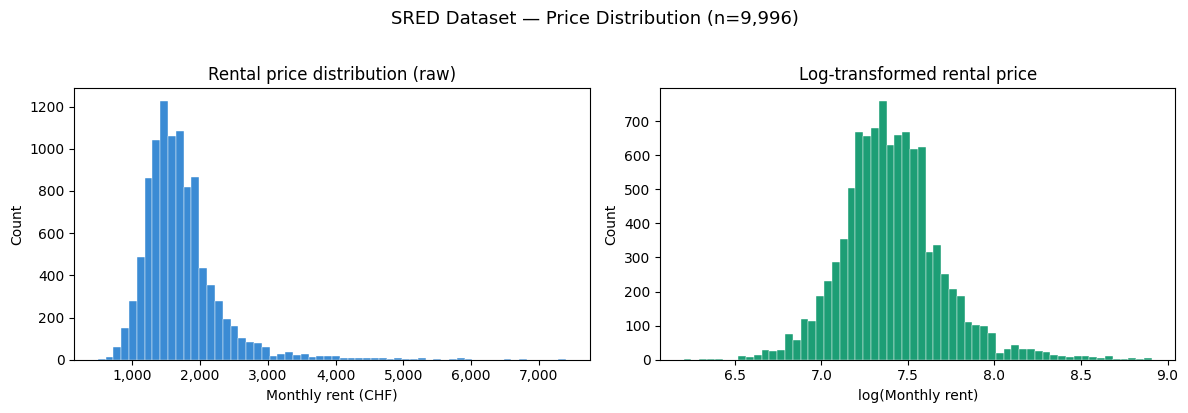

Figure saved.


In [12]:
# Price distribution
# This figure demonstrates that price is right-skewed,
# which justifies your choice to use log(price) as the model target.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw price
axes[0].hist(train['price'], bins=60, color='#3B8BD4', edgecolor='white', linewidth=0.3)
axes[0].set_title('Rental price distribution (raw)', fontsize=12)
axes[0].set_xlabel('Monthly rent (CHF)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Log-transformed price
axes[1].hist(np.log(train['price']), bins=60, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-transformed rental price', fontsize=12)
axes[1].set_xlabel('log(Monthly rent)')
axes[1].set_ylabel('Count')

plt.suptitle('SRED Dataset — Price Distribution (n=9,996)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig1_price_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


- The distribution of prices is positively skewed, meaning more extreme high values are less common.

- The majority of listings are concentrated between 1000 CHF and 2500 CHF but values extend up to 7000 CHF.

- To address the skewness of price, a log_price variable was created which transformed the distribution to be more symmetric/closer to a normal distribution.


### Log-Normality Test (Shapiro-Wilk)

---

We test whether log(price) follows a normal distribution.

A high p-value supports the log-transformation choice and justifies using `log_price' as the model target.

In [14]:
log_price = np.log(train['price'])

# Shapiro-Wilk requires n ≤ 5000; we sample 500 with a fixed seed for reproducibility
stat, p_value = stats.shapiro(log_price.sample(500, random_state=42))

skew_raw = train['price'].skew()
skew_log = log_price.skew()

print(f"Shapiro-Wilk test on log(price) [n=500 sample]:")
print(f"  W-statistic : {stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print(f"\nSkewness — raw price  : {skew_raw:.3f}")
print(f"Skewness — log price  : {skew_log:.3f}")

Shapiro-Wilk test on log(price) [n=500 sample]:
  W-statistic : 0.9113
  p-value     : 0.0000

Skewness — raw price  : 2.799
Skewness — log price  : 0.678


- p-value = 0.0000 which means log(price) is not strictly normal.
- This is expected with a sample size of 9,996 since Shapiro-Wilk is hypersensitive at large samples and rejects normality for even minor deviations.

-  The skewness drop: raw price skewness of 2.799 changed to 0.678 after log-transform, which is a substantial improvement and justifies the transformation.

- The log-transformed distribution is close enough to normal for tree-based models like XGBoostm, which don't assume normality anyway, but benefit from a less extreme target range.


### Feature Correlation
---

Pairwise correlations are examined among the tabular features to understand multicollinearity and identify which variables carry the most signal for price prediction.

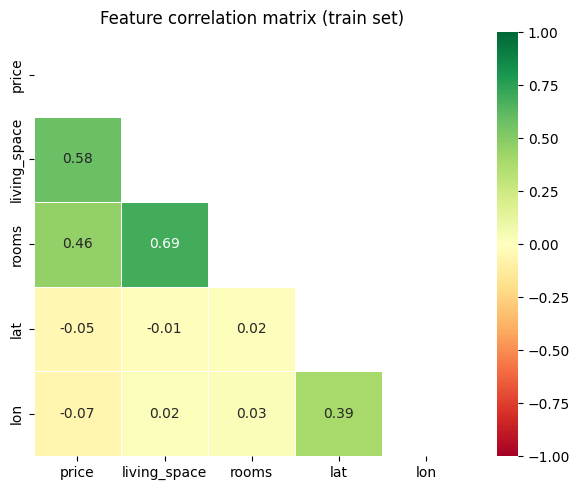

Notable correlations:
  price ↔ living_space : 0.58
  price ↔ rooms        : 0.46
  living_space ↔ rooms : 0.69


In [16]:
#Correlation Heatmap
corr = train[['price', 'living_space', 'rooms', 'lat', 'lon']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature correlation matrix (train set)', fontsize=12)
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Key takeaways
print("Notable correlations:")
print(f"  price ↔ living_space : {corr.loc['price','living_space']:.2f}")
print(f"  price ↔ rooms        : {corr.loc['price','rooms']:.2f}")
print(f"  living_space ↔ rooms : {corr.loc['living_space','rooms']:.2f}")

- living_space is the strongest single predictor of price (r = 0.58), followed by rooms (r = 0.46)
- living_space and rooms are highly collinear (r = 0.69), worth noting as a potential multicollinearity consideration

- lat and lon show near-zero linear correlations with price (−0.05, −0.07).  This indicates that location matters spatially but not linearly, which motivates using coordinates as model inputs rather than relying on correlation alone.

### Spatial Distribution
---

Location tends to be one of the strongest determinants of rental price.
This scatter plot maps all listings by latitude/longitude, colored by `log(price)` to reveal spatial price gradients across Switzerland.

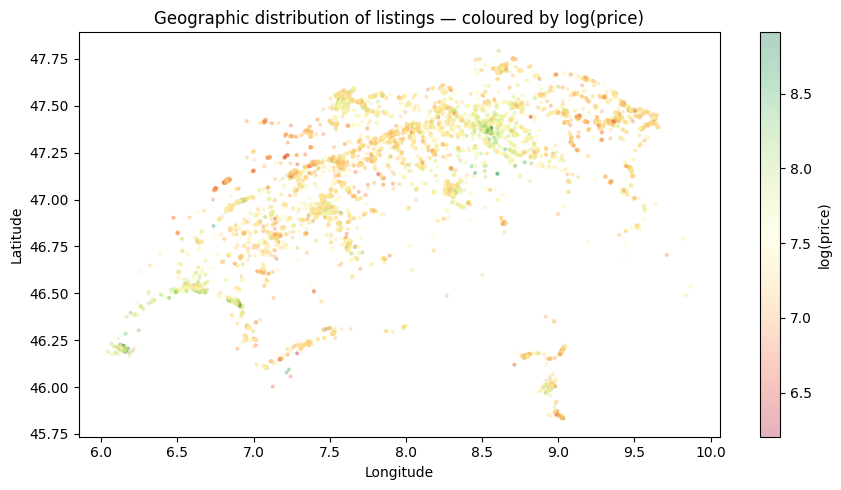

In [17]:
#Geographic Distribution
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    train['lon'], train['lat'],
    c=np.log(train['price']),   # log-scale colour avoids outlier wash-out
    cmap='RdYlGn', alpha=0.3, s=4
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log(price)')
ax.set_title('Geographic distribution of listings — coloured by log(price)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('fig3_geographic_distribution.png', bbox_inches='tight')
plt.show()

- Listings follow Switzerland's main urban cities. Zurich (approx. 8.5°E), Geneva (approx. 6.1°E), Bern (approx 7.5°E) are clearly visible as denser clusters.
- Higher priced listings (in green) concentrate around Zurich and Lake Geneva while lower-priced (in red and orange) appear in more rural southern/alpine regions.
- The near-zero lat/lon correlations from the heatmap make sense as price doesn't increase linearly with coordinates, it clusters by urban proximity, which raw lat/lon can't fully capture without spatial encoding.

In [19]:
# Add log_price column to both splits
train['log_price'] = np.log(train['price'])
test['log_price']  = np.log(test['price'])

#Save Processed Data

In [20]:
train.to_csv('train_processed.csv', index=False)
test.to_csv('test_processed.csv', index=False)